
<meta name="viewport" content="width=device-width, initial-scale=1">
<meta name="description" content="Explore satisfaction, tenure, workload, and churn patterns at Salifort Motors through Python-based exploratory data analysis.">
<title>Classified: At-Risk – Salifort Churn Prediction</title>
<link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.3/dist/css/bootstrap.min.css" rel="stylesheet">
<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.5.2/css/all.min.css">
<link rel="stylesheet" href="../static/css/styles.css">
<link rel="icon" href="favicon.ico" type="image/ico" />


<!-- <body> -->
<!-- Navigation-->
<nav class="navbar navbar-expand-lg navbar-light fixed-top" id="mainNav">
    <div class="container px-4 px-lg-5">
        <a class="navbar-brand" href="../index.html">Home</a>
        <button class="navbar-toggler" type="button" data-bs-toggle="collapse" data-bs-target="#navbarResponsive" aria-controls="navbarResponsive" aria-expanded="false" aria-label="Toggle navigation">
            Menu
            <i class="fas fa-bars"></i>
        </button>
        <div class="collapse navbar-collapse" id="navbarResponsive">
            <ul class="navbar-nav ms-auto py-4 py-lg-0">
                <li class="nav-item"><a class="nav-link px-lg-3 py-3 py-lg-4" href="../index.html">Executive Summary</a></li>
                <!-- <li class="nav-item"><a class="nav-link px-lg-3 py-3 py-lg-4" href="eda.html">Exploratory Data Analysis</a></li> -->
                <li class="nav-item"><a class="nav-link px-lg-3 py-3 py-lg-4" href="models.html">Model Construction & Validation</a></li>
                <li class="nav-item"><a class="nav-link px-lg-3 py-3 py-lg-4" href="initial_work.html">Reference: Model Development</a></li>
            </ul>
        </div>
    </div>
</nav>

<div class="project-banner">
  <span class="project-banner-main">
    <span class="classified">Classified:</span>
    <span class="at-risk">At-Risk</span>
  </span>
  <span class="project-banner-sub">Salifort Employee Churn Prediction</span>
</div>

In [1]:
from IPython.display import display, HTML

display(
    HTML(
        """
<img src="../resources/images/header_small.png" style="max-width:100%; height:auto; display:block; margin:auto;">
"""
    )
)

<link rel="stylesheet" href="../static/css/styles.css">
<h2 id="title" style="text-align: center; width: 80%;">Exploratory Data Analysis</h2>

<br>

#### Understanding employee turnover at Salifort Motors

*Bryan Johns*

June 2025

# Table of Contents

- [Description and Deliverables](#description-and-deliverables)
- [Data Dictionary](#data-dictionary)
- [Descriptive Statistics](#descriptive-statistics)
  - [Outliers](#outliers)
- [Exploratory Data Analysis](#eda)
  - [Overview Plots](#summary-visualizations)
  - [Satisfaction Levels](#scatter-plots)
  - [Tenure](#tenure)
  - [Number of Projects](#number-of-projects)
  - [Salary & Promotions](#salary)
  - [Work Accident](#work-accident)
  - [Department](#department)
  - [Correlation Matrix](#correlation-matrix)
- [Insights](#insights)

<div class="circle-separator-anchor"></div>

<a id="description-and-deliverables"></a>

# **Description and Deliverables**
---

[Back to top](#)

The hypothetical HR department at the fictional Salifort Motors collected employee data to improve satisfaction. They requested data-driven suggestions based on an analysis of this data. The main question is: what factors are likely to make an employee leave the company?

The **goal** of this project is to **analyze the data** and build a model to **predict employee attrition**. By identifying which employees are likely to leave, it may be possible to determine the factors contributing to their departure. The model should be interpretable so HR can design targeted interventions to improve retention. Improving retention can reduce the costs associated with hiring and training new employees.

**Stakeholders:**  
The primary stakeholder is the Human Resources (HR) department, as they will use the results to inform retention strategies. Secondary stakeholders include C-suite executives who oversee company direction, managers implementing day-to-day retention efforts, employees (whose experiences and outcomes are directly affected), and, indirectly, customers, since employee satisfaction can impact customer satisfaction.

**Ethical Considerations:**  
- Ensure employee data privacy and confidentiality throughout the analysis.
- Avoid introducing or perpetuating bias in model predictions (e.g., not unfairly targeting specific groups).
- Maintain transparency in how predictions are generated and how they will be used in HR decision-making.

### This page summarizes the first part of the project: exploratory data analysis.


<div class="circle-separator-anchor"></div>

<a id="data-dictionary"></a>

# **Data Dictionary**
---

[Back to top](#)

The dataset contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

In [2]:
# Import packages
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

import warnings

warnings.filterwarnings("ignore")

<div class="circle-separator-anchor"></div>

<a id="descriptive-statistics"></a>

# **Descriptive Statistics**
---

[Back to top](#)

**Initial Data Observations:**  
- The workforce displays moderate satisfaction and generally high performance reviews.
- Typical tenure is 3–4 years, with most employees (98%) not promoted recently.
- Workplace accidents are relatively rare (14%).
- Most employees are in lower salary bands and concentrated in sales, technical, and support roles.
- About 24% of employees have left the company.
- No extreme outliers, though a few employees have unusually long tenures or high monthly hours.

**Data Wrangling**

During initial data exploration, several basic data cleaning steps were taken. Columns were renamed to standardized snake_case format for consistency and easier coding. I confirmed there were no missing values, reducing the risk of bias or errors. Outliers were explored but not removed at this stage; they will be addressed as needed during modeling.

Most importantly, there were 3,008 duplicate rows in the dataset. Since it is highly improbable for two employees to have identical responses across all columns, these **duplicate entries were removed** from the analysis.

Start with a look at the first few rows of data:

In [3]:
# Load dataset into a dataframe
df0 = pd.read_csv("../resources/HR_capstone_dataset.csv")


# Display first few rows of the dataframe
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


Below are descriptive statistics for numerical data, followed by categorical data (department and salary) and summary observations.

In [4]:
# Gather descriptive statistics about the data
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


Department value counts and percentages:

In [5]:
# Format department names for better readability
special_cases = {"RandD": "R and D", "IT": "IT", "hr": "HR"}


def format_department(label):
    label = label.replace("_", " ")
    label = special_cases.get(label.replace(" ", ""), label.title())
    return label

In [6]:
# Department value counts and percent
dept_counts = df0.Department.value_counts()
dept_percent = df0.Department.value_counts(normalize=True) * 100
dept_summary = pd.DataFrame({"Count": dept_counts, "Percent": dept_percent.round(2)})
# reset index so Department is a column, format department names
dept_summary = dept_summary.reset_index().rename(columns={"index": "Department"})
dept_summary["Department"] = dept_summary["Department"].apply(format_department)
# format percent column
dept_summary["Percent"] = dept_summary["Percent"].astype(float).map("{:.2f}".format)
display(dept_summary.style.hide(axis="index"))

Department,Count,Percent
Sales,4140,27.60
Technical,2720,18.13
Support,2229,14.86
IT,1227,8.18
Product Mng,902,6.01
Marketing,858,5.72
R and D,787,5.25
Accounting,767,5.11
HR,739,4.93
Management,630,4.20


Salary value counts and percentages:

In [7]:
# Salary value counts and percent
salary_counts = df0.salary.value_counts()
salary_percent = df0.salary.value_counts(normalize=True) * 100
salary_summary = pd.DataFrame({"Count": salary_counts, "Percent": salary_percent})
salary_summary.index = salary_summary.index.str.title()
salary_summary = salary_summary.reset_index().rename(columns={"index": "Salary"})
salary_summary["Percent"] = salary_summary["Percent"].astype(float).map("{:.2f}".format)
display(salary_summary.style.hide(axis="index"))

salary,Count,Percent
Low,7316,48.78
Medium,6446,42.98
High,1237,8.25


#### **Observations from descriptive statistics**

- **satisfaction_level:** Employee job satisfaction scores range from 0.09 to 1.0, with an average of about 0.61. The distribution is fairly wide (std ≈ 0.25), suggesting a mix of satisfied and dissatisfied employees.
- **last_evaluation:** Performance review scores are generally high (mean ≈ 0.72), ranging from 0.36 to 1.0, with most employees scoring above 0.56.
- **number_project:** Employees typically work on 2 to 7 projects, with a median of 4 projects.
- **average_monthly_hours:** The average employee works about 201 hours per month, with a range from 96 to 310 hours, indicating some employees work significantly more than others.
- **time_spend_company:** Most employees have been with the company for 2 to 10 years, with a median of 3 years. There are a few long-tenure employees (up to 10 years), but most are around 3–4 years.
- **Work_accident:** About 14% of employees have experienced a workplace accident.
- **left:** About 24% of employees have left the company (mean ≈ 0.24), so roughly one in four employees in the dataset is a leaver.
- **promotion_last_5years:** Very few employees (about 2%) have been promoted in the last five years.
- **department:** The largest departments are sales, technical, and support, which together account for over half of the workforce. Other departments are notably smaller.
- **salary:** Most employees are in the low (49%) or medium (43%) salary bands, with only a small proportion (8%) in the high salary band.

**Summary:**  
The data shows a workforce with moderate satisfaction, generally high performance reviews, and a typical tenure of 3–4 years. Most employees have not been promoted recently, and workplace accidents are relatively uncommon. Most employees are in lower salary bands and concentrated in sales, technical, and support roles. There is a notable proportion of employees who have left. There are no extreme outliers, but a few employees have unusually long tenures or high monthly hours.

In [8]:
# Rename columns as needed
df0.rename(
    columns={
        "Department": "department",
        "Work_accident": "work_accident",
        "average_montly_hours": "average_monthly_hours",
        "time_spend_company": "tenure",
    },
    inplace=True,
)


# Display all column names after the update
# df0.columns

In [9]:
# Drop duplicates and save resulting dataframe in a new variable as needed
df = df0.drop_duplicates()


# Display first few rows of new dataframe as needed
# print(df.info())
# df.head()

<div class="circle-separator-anchor"></div>

<a id="outliers"></a>

## Outliers
---

[Back to top](#)

Long-term employees (those with more than five years at the company) are statistical outliers in this dataset. These cases will be excluded from logistic regression models during <a href="./notebooks/models.html">Model Construction &amp; Validation</a> because logistic regression is particularly sensitive to outliers.

Employees with exceptionally high average monthly hours or an unusually high or low number of projects may also be considered outliers. However, these cases are not easily detected in overall summary statistics or aggregate plots, as their impact is masked by the larger population of typical employees. Aggregate statistics can hide important subgroup patterns, which will be explored further during EDA. These subgroups will remain in the data for model construction, as they may provide valuable insights into attrition risk.

In [10]:
# Boxplot of `average_monthly_hours` to visualize distribution and detect outliers
# plt.figure(figsize=(6, 2))
# sns.boxplot(x=df["average_monthly_hours"])
# plt.title("Boxplot of Average Monthly Hours")
# plt.xlabel("Average Monthly Hours")
# plt.show()

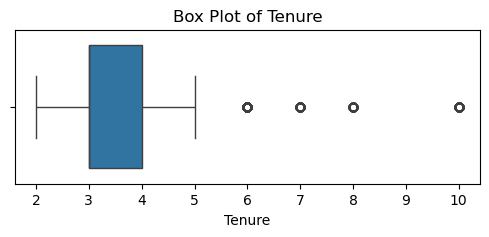

In [11]:
# Create a boxplot to visualize distribution of `tenure` and detect any outliers
plt.figure(figsize=(6, 2))
sns.boxplot(x=df["tenure"])
plt.title("Box Plot of Tenure")
plt.xlabel("Tenure")
plt.show()

In [12]:
# Determine the number of rows containing outliers
q1 = df.tenure.quantile(0.25)
q3 = df.tenure.quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

# Filter the dataframe to find outliers
outliers = df[df.tenure > upper_bound]

# Display the number of outliers
# print(f"Number of tenure outliers: {len(outliers)}")
# print(f"Outliers percentage of total: {len(outliers) / len(df) * 100:.2f}%")

Number of tenure outliers: 824

Outliers percentage of total: 6.87%

<div class="circle-separator-anchor"></div>

<a id="eda"></a>

# **Exploratory Data Analysis**

---

[Back to top](#)

<div class="emphasis-box">
    Two major groups of employees left the company:<br><br>
    <ul>
        <li><b>Overworked and Miserable:</b> These employees had low satisfaction but were assigned a high number of projects (6–7) and worked 250–300 hours per month. Notably, 100% of employees with 7 projects left.</li><br>
        <li><b>Underworked and Dissatisfied:</b> These employees had low satisfaction and worked fewer hours and projects. They may have been fired. Alternately, they may have given notice or had already mentally checked out and were assigned less work.</li>
    </ul>
</div>

Employees working on 3–4 projects generally stayed. Most groups worked more than a typical 40-hour workweek.

Attrition is highest at the 4–5 year mark, with a sharp drop-off in departures after 5 years. This suggests a critical window for retention efforts. Employees who make it past 5 years are much more likely to stay.

Both leavers and stayers tend to have similar evaluation scores. Notably, some employees with high evaluations still leave, often those who are overworked. This suggests that strong performance alone does not guarantee retention if other factors (like satisfaction or workload) are problematic.

**Relationships Between Variables:**

- **Satisfaction level** is the strongest predictor of attrition. Employees who left had much lower satisfaction than those who stayed.
- **Number of projects** and **average monthly hours** show a non-linear relationship: both underworked and overworked employees are more likely to leave, while those with a moderate workload tend to stay.
- **Employee evaluation** (last performance review) has a weaker relationship with attrition compared to satisfaction or workload.
- **Tenure** shows a moderate relationship with attrition: employees are most likely to leave at the 4–5 year mark, with departures dropping sharply after 5 years.
- **Promotion in the last 5 years** is rare, and lack of promotion is associated with higher attrition.
- **Department** and **salary** have only minor effects on attrition compared to satisfaction and workload.
- **Work accidents** are slightly associated with lower attrition, possibly due to increased support after an incident.

**Distributions in the Data:**

- Most variables (satisfaction, evaluation, monthly hours) are broadly distributed, with some skewness.
- **Tenure** is concentrated around 3–4 years, with few employees beyond 5 years.
- **Number of projects** is typically 3–4, but a small group has 6–7 projects (most of whom left).
- **Salary** is heavily skewed toward low and medium bands.
- There are no extreme outliers, but a few employees have unusually high tenure or monthly hours.

**Ethical Considerations:**

- Ensure employee data privacy and confidentiality.
- Avoid introducing or perpetuating bias in analysis or modeling.
- Be transparent about how findings and predictions will be used.
- Consider the impact of recommendations on employee well-being and fairness.

**Note:**  
This data is clearly synthetic. It's too clean, and the clusters in the charts are much neater than what you’d see in real-world HR data.


Before starting, look at the distribution of employees who left versus those who stayed. The attrition breakdown is pretty normal for industry. But this imbalance matters when training a predictive model.

In [13]:
# Get numbers of people who left vs. stayed
# Get percentages of people who left vs. stayed
left_counts = df.left.value_counts()
left_percent = df.left.value_counts(normalize=True) * 100

left_summary = pd.DataFrame({"Count": left_counts, "Percent": left_percent})

left_summary.index = left_summary.index.map({0: "Stayed", 1: "Left"})
left_summary = left_summary.reset_index().rename(columns={"left": ""})
left_summary["Percent"] = left_summary["Percent"].astype(float).map("{:.2f}".format)
display(left_summary.style.hide(axis="index"))

,Count,Percent
Stayed,10000,83.40
Left,1991,16.60


<div class="circle-separator-anchor"></div>

<a id="summary-visualizations"></a>

## Overview Plots
---

[Back to top](#)

### Visualizing Feature Distributions and Relationships by Employee Attrition

These are overview plots that provide a broad look at the data. After these, we’ll focus on individual features in more detail. The goal here is to give an initial sense of the dataset’s structure and key patterns.

The following **pairplots** show the relationships between features, with the diagonal displaying each feature’s distribution.


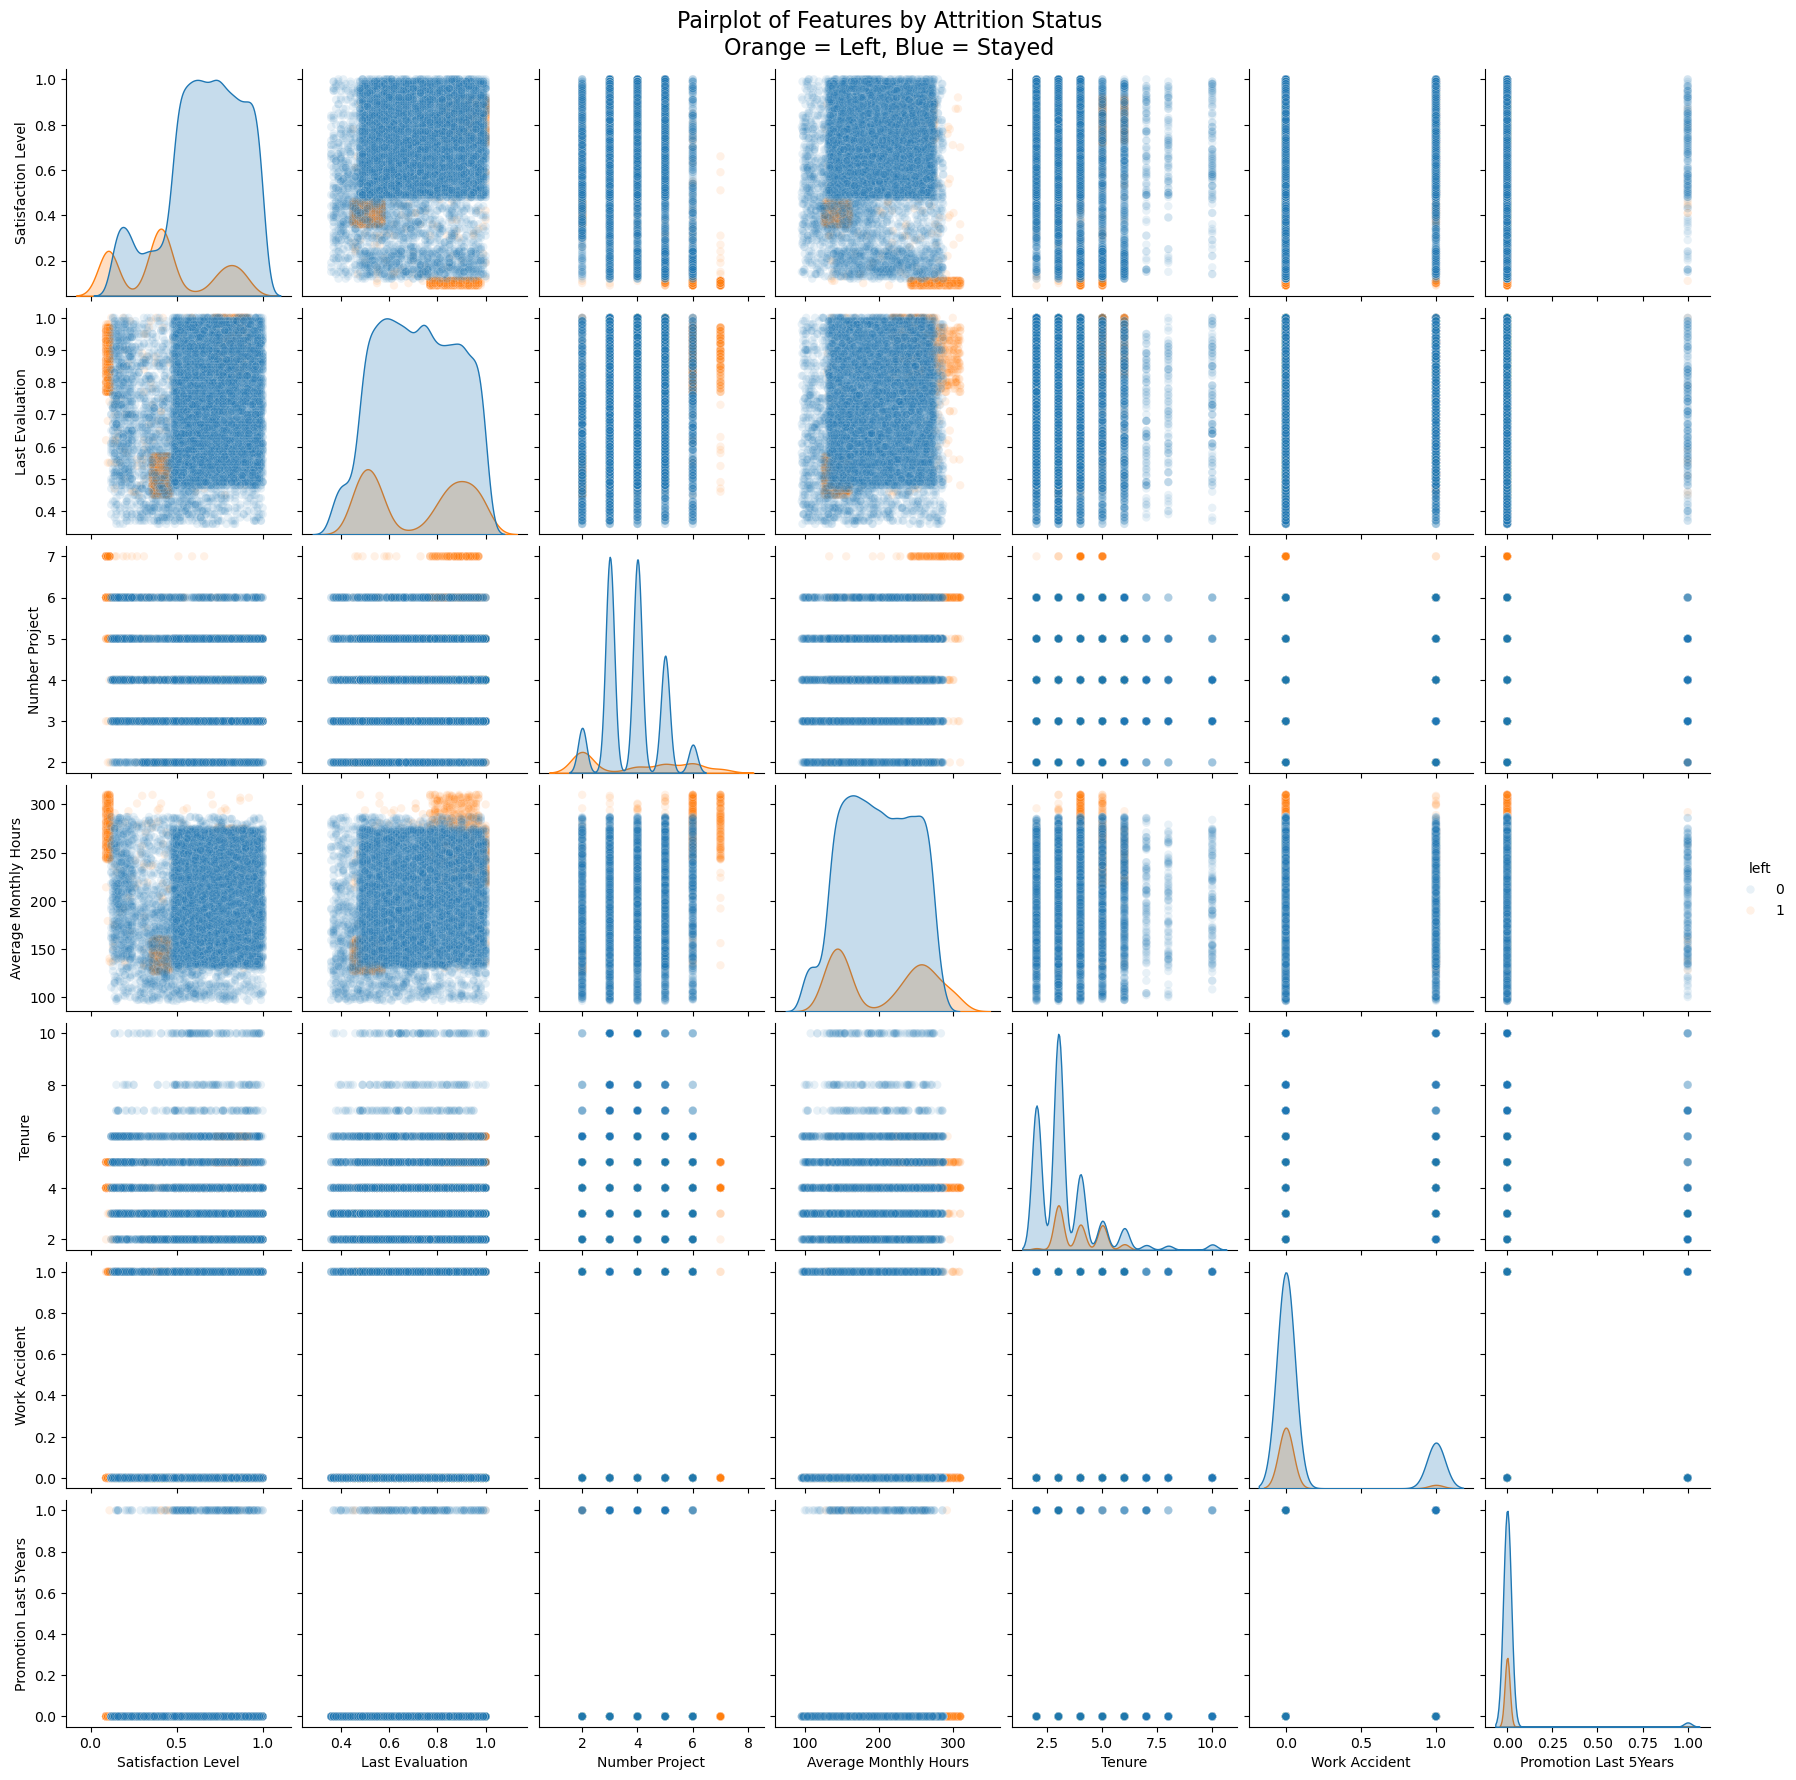

In [14]:
# Pairplot to visualize relationships between features
g = sns.pairplot(df, hue="left", diag_kind="kde", plot_kws={"alpha": 0.1})
g.fig.suptitle(
    "Pairplot of Features by Attrition Status\nOrange = Left, Blue = Stayed",
    y=1.02,
    fontsize=16,
)

# format all axis labels
for ax in g.axes.flatten():
    if ax is not None:
        xlabel = ax.get_xlabel()
        ylabel = ax.get_ylabel()
        if xlabel:
            ax.set_xlabel(xlabel.replace("_", " ").title())
        if ylabel:
            ax.set_ylabel(ylabel.replace("_", " ").title())

plt.show()

**Boxplots** summarize the overall distribution of each feature. However, as noted earlier, aggregate plots can sometimes hide important subgroups or outliers.

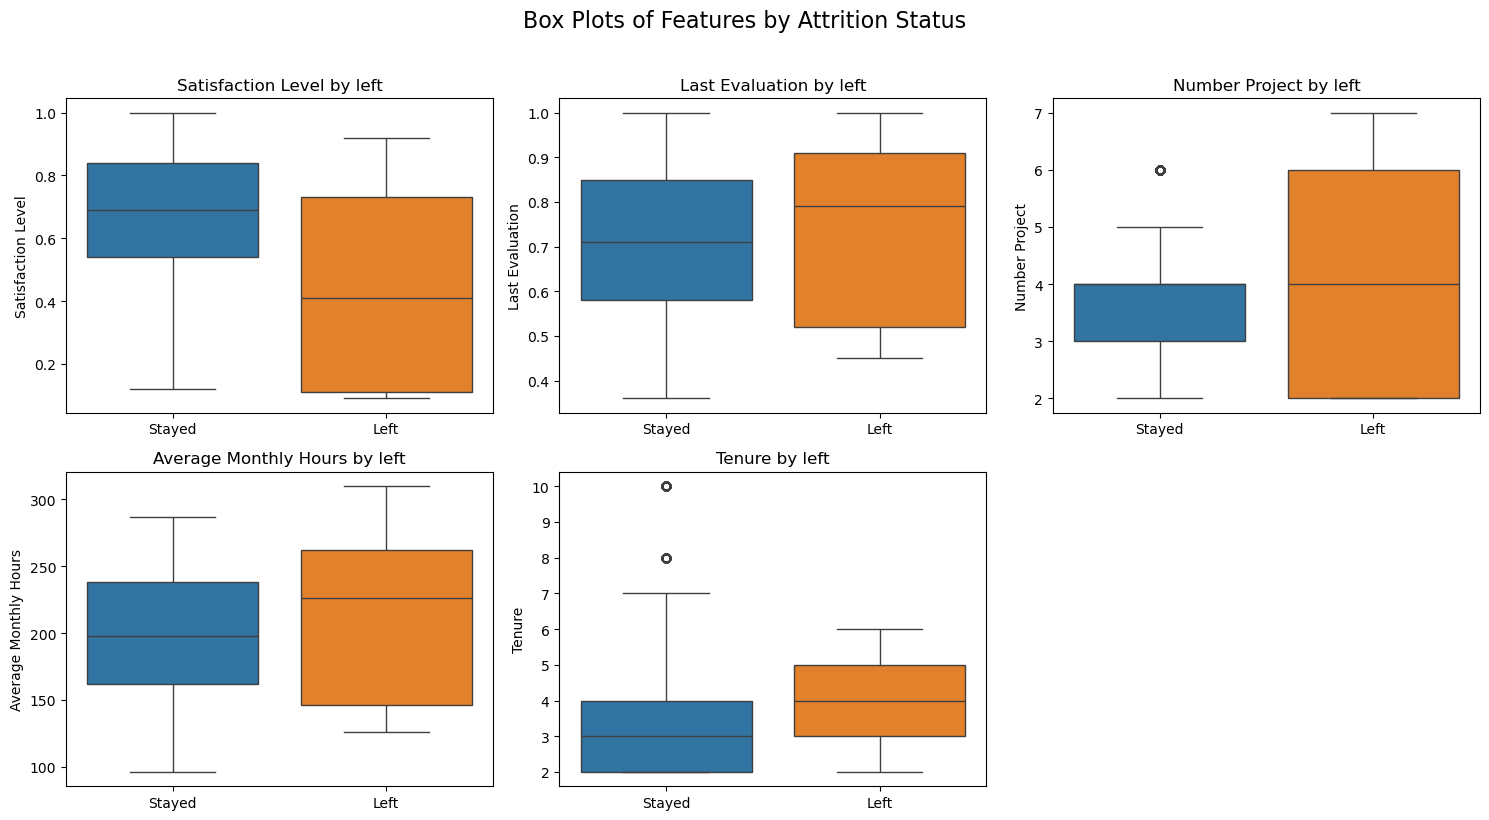

In [15]:
# Boxplots to visualize distributions of numerical features by `left`
numerical_cols = [
    "satisfaction_level",
    "last_evaluation",
    "number_project",
    "average_monthly_hours",
    "tenure",
]

plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    ax = sns.boxplot(x="left", y=col, data=df, hue="left")
    # format column name for display
    display_col = col.replace("_", " ").title()
    plt.title(f"{display_col} by left")
    ax.set_xticklabels(["Stayed", "Left"])
    ax.get_legend().remove()
    ax.set_xlabel("")
    ax.set_ylabel(display_col)

plt.suptitle("Box Plots of Features by Attrition Status", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Violin plots** are especially useful here, as they reveal the presence of distinct subgroups. For example, in `satisfaction_level`, you can see the extremely miserable and somewhat dissatisfied employees, along with those who left for more typical reasons. In `last_evaluation` and `average_monthly_hours`, employees who left cluster at both extremes, while those who stayed are more evenly distributed. For `number_project`, leavers are concentrated at both the low and high ends, and for `tenure`, there is a noticeable spike in departures around the 4–5 year mark.

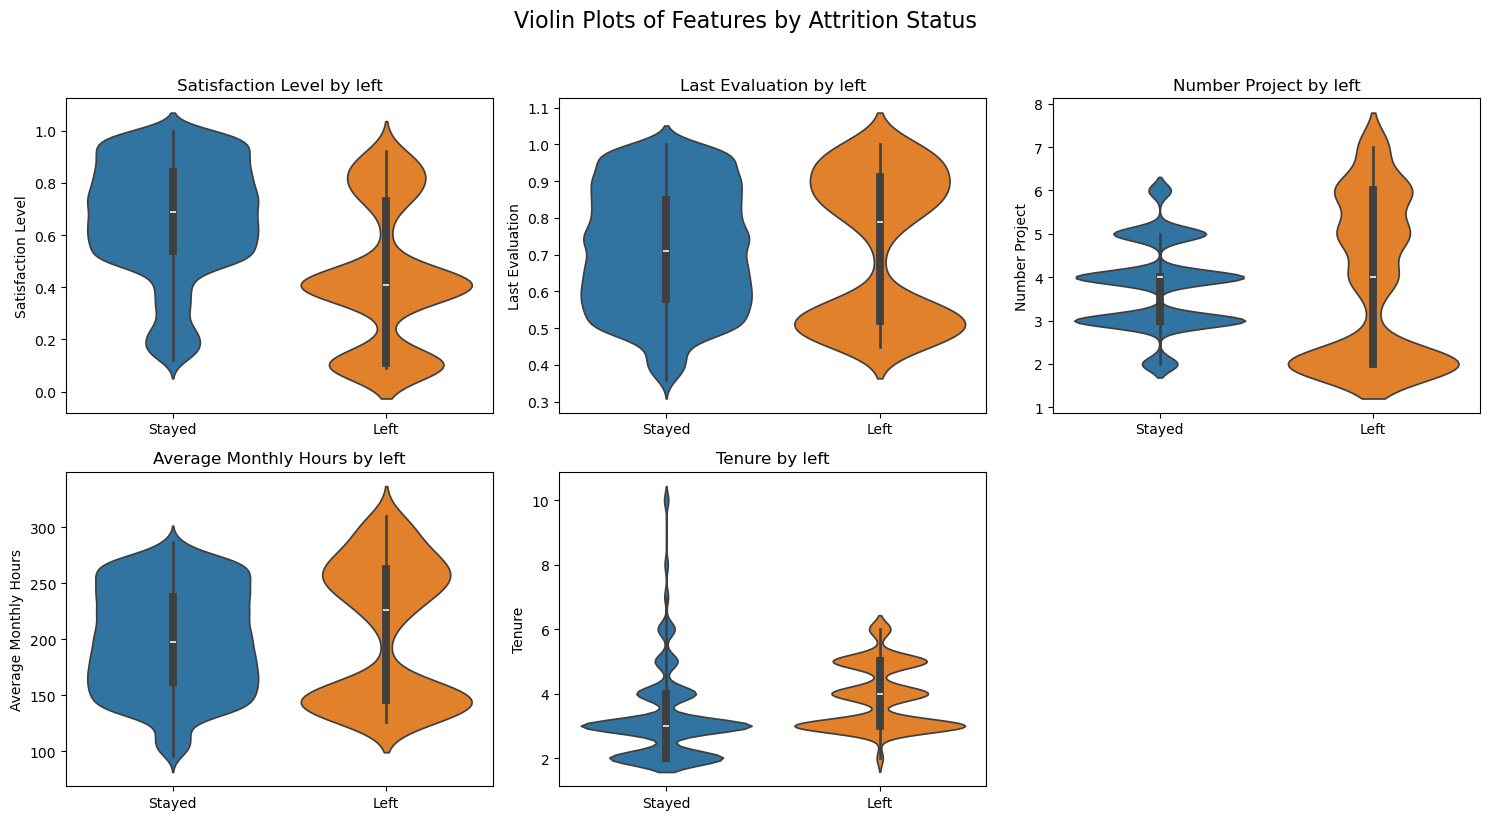

In [16]:
# Violin plots to visualize distributions of numerical features by `left`
numerical_cols = [
    "satisfaction_level",
    "last_evaluation",
    "number_project",
    "average_monthly_hours",
    "tenure",
]

plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    ax = sns.violinplot(x="left", y=col, data=df, inner="box", hue="left")
    # format column name for display
    display_col = col.replace("_", " ").title()
    plt.title(f"{display_col} by left")
    ax.set_xticklabels(["Stayed", "Left"])
    ax.get_legend().remove()
    ax.set_xlabel("")
    ax.set_ylabel(display_col)

plt.suptitle("Violin Plots of Features by Attrition Status", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Finally, we include **histograms** for each feature, **first normalized**, to compare proportions between leavers and stayers...

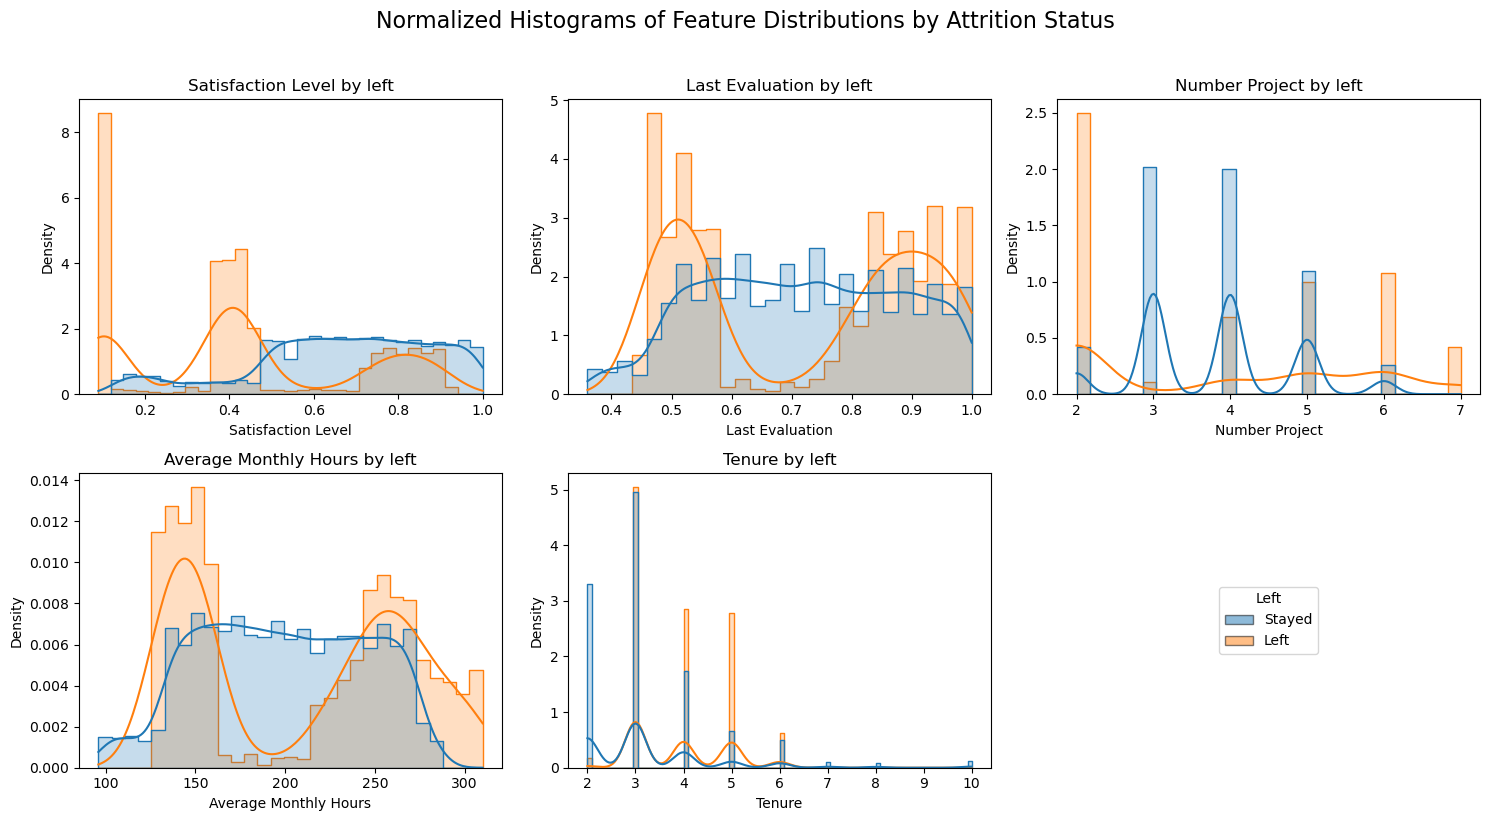

In [17]:
# Histograms to visualize distributions of numerical features
numerical_cols = [
    "satisfaction_level",
    "last_evaluation",
    "number_project",
    "average_monthly_hours",
    "tenure",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(numerical_cols):
    ax = axes.flat[i]
    sns.histplot(
        data=df,
        x=col,
        hue="left",
        kde=True,
        element="step",
        stat="density",
        common_norm=False,
        ax=ax,
        legend=False,  # no individual legends
    )
    # format column name for display
    display_col = col.replace("_", " ").title()
    ax.set_title(f"{display_col} by left")
    ax.set_xlabel(display_col)

# custom legend in the sixth (empty) subplot
palette = sns.color_palette()  # get defatult seaborn palette
handles = [
    Patch(facecolor=palette[0], edgecolor="k", alpha=0.5, label="Stayed"),
    Patch(facecolor=palette[1], edgecolor="k", alpha=0.5, label="Left"),
]
axes.flat[5].axis("off")  # hide axes
axes.flat[5].legend(handles=handles, title="Left", loc="center")

plt.suptitle(
    "Normalized Histograms of Feature Distributions by Attrition Status",
    fontsize=16,
    y=1.02,
)

plt.tight_layout()

plt.show()

...and then as raw counts:

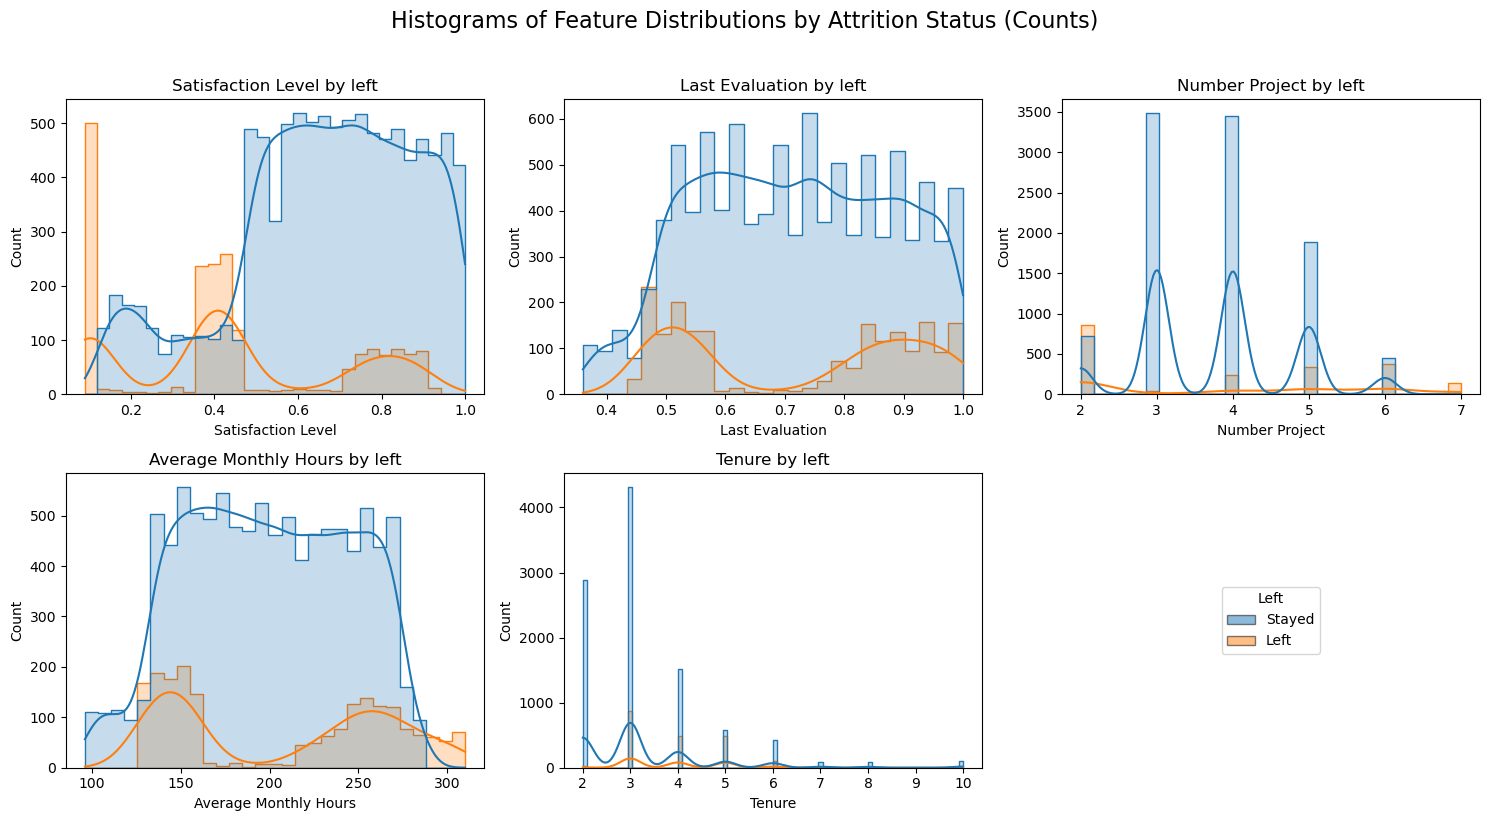

In [18]:
# Histograms to visualize distributions of numerical features (showing true count)
numerical_cols = [
    "satisfaction_level",
    "last_evaluation",
    "number_project",
    "average_monthly_hours",
    "tenure",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(numerical_cols, 1):
    ax = axes.flat[i - 1]
    plt.subplot(2, 3, i)
    sns.histplot(
        data=df, x=col, hue="left", kde=True, element="step", stat="count", legend=False
    )
    # format column name for display
    display_col = col.replace("_", " ").title()
    ax.set_title(f"{display_col} by left")
    ax.set_xlabel(display_col)

# custom legend in the sixth (empty) subplot
palette = sns.color_palette()  # get defatult seaborn palette
handles = [
    Patch(facecolor=palette[0], edgecolor="k", alpha=0.5, label="Stayed"),
    Patch(facecolor=palette[1], edgecolor="k", alpha=0.5, label="Left"),
]
axes.flat[5].axis("off")  # hide axes
axes.flat[5].legend(handles=handles, title="Left", loc="center")

plt.suptitle(
    "Histograms of Feature Distributions by Attrition Status (Counts)",
    fontsize=16,
    y=1.02,
)

plt.tight_layout()

plt.show()

<div class="circle-separator-anchor"></div>

<a id="scatter-plots"></a>

## Satisfaction Levels
---

[Back to top](#)

#### These visualizations dramatically illustrate the two main clusters of employees who left.

There are two prominent clusters among employees who left: one group with very low satisfaction who worked long hours, and another group who worked fewer than 40 hours per week and reported moderate dissatisfaction. All of the employees who worked the longest hours left.

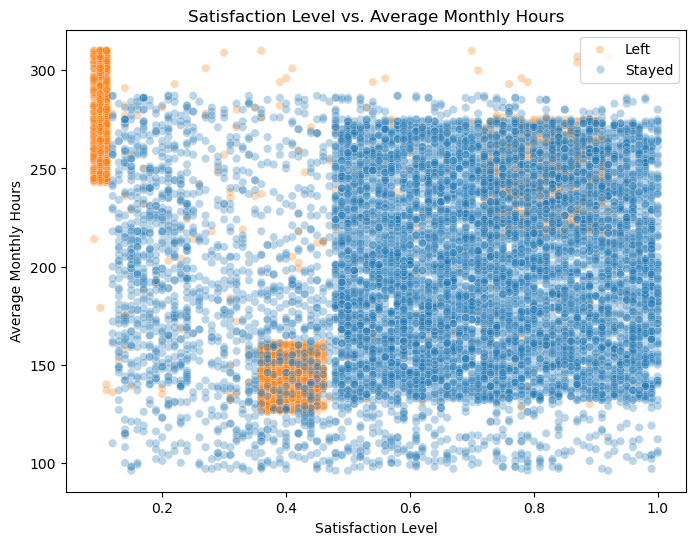

In [19]:
# Plot satisfaction vs. hours worked, colored by left
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="satisfaction_level",
    y="average_monthly_hours",
    hue="left",
    alpha=0.3,
)
plt.title("Satisfaction Level vs. Average Monthly Hours")
plt.xlabel("Satisfaction Level")
plt.ylabel("Average Monthly Hours")
plt.legend(loc="upper right", labels=["Left", "Stayed"])
plt.show()

The pattern is similar among employees who left: those with very low satisfaction often received high evaluations, while those with moderate dissatisfaction tended to have relatively low evaluation scores.

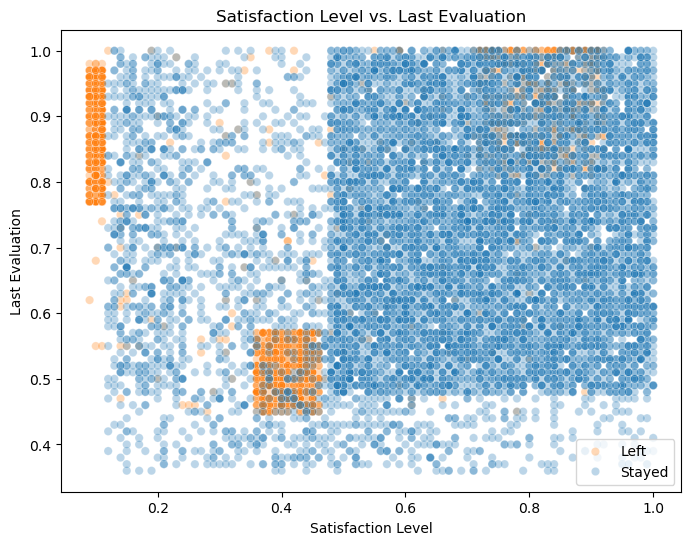

In [20]:
# Plot satisfaction level vs last evaluation, colored by left
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="satisfaction_level",
    y="last_evaluation",
    hue="left",
    alpha=0.3,
)
plt.title("Satisfaction Level vs. Last Evaluation")
plt.xlabel("Satisfaction Level")
plt.ylabel("Last Evaluation")
plt.legend(loc="lower right", labels=["Left", "Stayed"])
plt.show()

In [21]:
# Get mean and median satisfaction level for those who left vs. stayed
mean_satisfaction = df.groupby("left")["satisfaction_level"].mean()
median_satisfaction = df.groupby("left")["satisfaction_level"].median()

satisfaction_summary = pd.DataFrame(
    {"Mean": mean_satisfaction, "Median": median_satisfaction}
)

satisfaction_summary.index = satisfaction_summary.index.map({0: "Stayed", 1: "Left"})
satisfaction_summary = satisfaction_summary.reset_index().rename(columns={"left": ""})

satisfaction_summary["Mean"] = (
    satisfaction_summary["Mean"].astype(float).map("{:.3f}".format)
)
satisfaction_summary["Median"] = (
    satisfaction_summary["Median"].astype(float).map("{:.3f}".format)
)
display(satisfaction_summary.style.hide(axis="index"))

,Mean,Median
Stayed,0.667,0.690
Left,0.440,0.410


Above: Employees who left were, on average, 22.7% less satisfied (mean) and 28% less satisfied (median) than those who stayed.

Below: Working long hours does not guarantee a high evaluation, nor does a strong evaluation ensure a reasonable workload. Among leavers, the percentage of highly evaluated employees working long hours closely mirrors the pattern seen in satisfaction levels. Many top performers are being driven away.

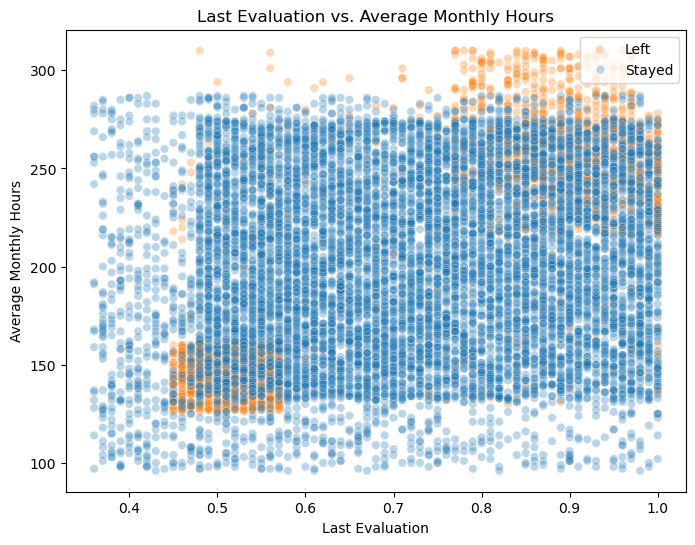

In [22]:
# Plot last evaluation vs. average monthly hours, colored by left
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="last_evaluation",
    y="average_monthly_hours",
    hue="left",
    alpha=0.3,
)
plt.title("Last Evaluation vs. Average Monthly Hours")
plt.xlabel("Last Evaluation")
plt.ylabel("Average Monthly Hours")
plt.legend(loc="upper right", labels=["Left", "Stayed"])
plt.show()

<div class="circle-separator-anchor"></div>

<a id="tenure"></a>

## Tenure
---

[Back to top](#)

Employees especially quit at the 4 and 5 year mark. Almost nobody quits after 5 years.


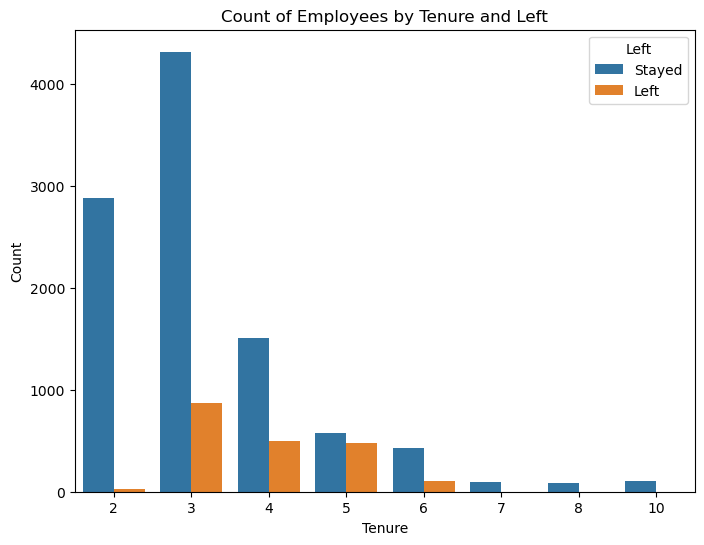

In [23]:
# Bar plot of tenure by left
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x="tenure", hue="left")
plt.title("Count of Employees by Tenure and Left")
plt.xlabel("Tenure")
plt.ylabel("Count")
plt.legend(title="Left", loc="upper right", labels=["Stayed", "Left"])
plt.show()

In [24]:
# Get total and percentage of employees by tenure and left
tenure_counts = df.groupby(["tenure", "left"]).size().unstack(fill_value=0)
tenure_percent = tenure_counts.div(tenure_counts.sum(axis=1), axis=0) * 100
tenure_summary = pd.DataFrame(
    {"Count": tenure_counts.stack(), "Percent": tenure_percent.stack()}
).reset_index()
tenure_summary.columns = ["Tenure", "Left", "Count", "Percent"]
tenure_summary["Left"] = tenure_summary["Left"].map({0: "Stayed", 1: "Left"})
tenure_summary["Percent"] = tenure_summary["Percent"].astype(float).map("{:.2f}".format)
display(tenure_summary.style.hide(axis="index"))

Tenure,Left,Count,Percent
2,Stayed,2879,98.93
2,Left,31,1.07
3,Stayed,4316,83.16
3,Left,874,16.84
4,Stayed,1510,75.31
4,Left,495,24.69
5,Stayed,580,54.61
5,Left,482,45.39
6,Stayed,433,79.89
6,Left,109,20.11


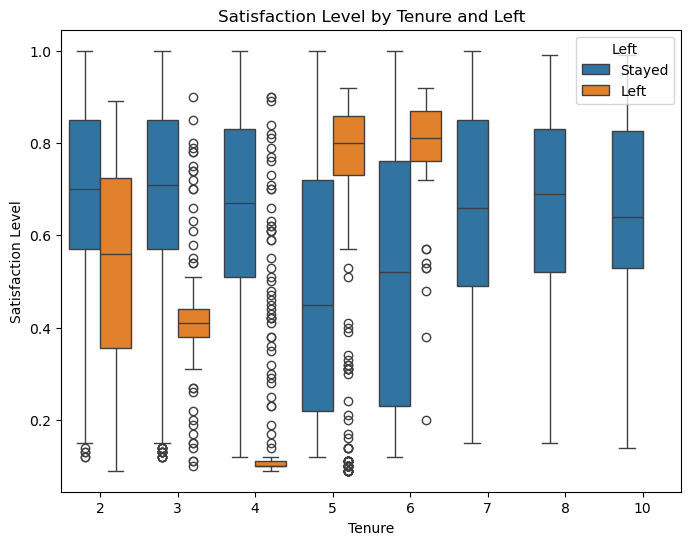

In [25]:
# Box plot of tenure vs satisfaction level, split by left
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="tenure", y="satisfaction_level", hue="left")
plt.title("Satisfaction Level by Tenure and Left")
plt.xlabel("Tenure")
plt.ylabel("Satisfaction Level")
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["Stayed", "Left"], title="Left", loc="upper right")
plt.show()

A band of employees with low satisfaction is especially evident at four years of tenure.


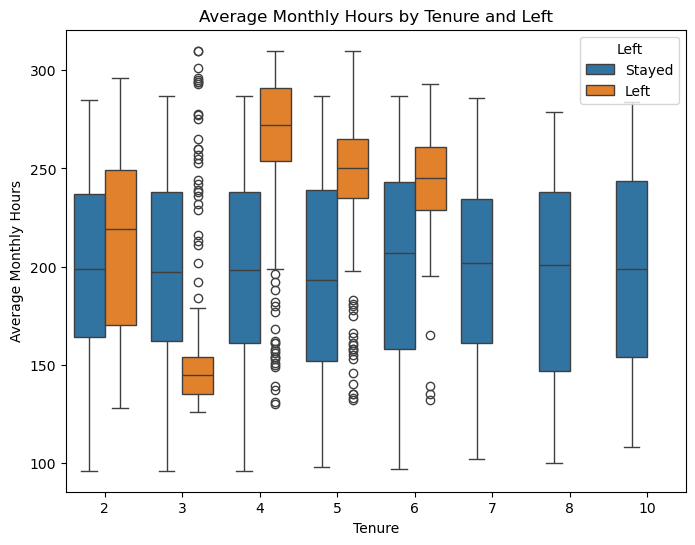

In [26]:
# Boxplot of tenure vs average monthly hours, split by left
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="tenure", y="average_monthly_hours", hue="left")
plt.title("Average Monthly Hours by Tenure and Left")
plt.xlabel("Tenure")
plt.ylabel("Average Monthly Hours")
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["Stayed", "Left"], title="Left", loc="upper right")
plt.show()

There is a clear grouping of leavers who consistently worked long hours (i.e., many in excess of a 60-hour work week). In fact, most employees at this company work above a standard 40-hour work week.

<div class="circle-separator-anchor"></div>

<a id="number-of-projects"></a>

## Number of Projects
---

[Back to top](#)

The number of projects is a strong predictor of attrition. Employees at both the low and high extremes are more likely to leave, and notably, all employees with 7 projects left the company.

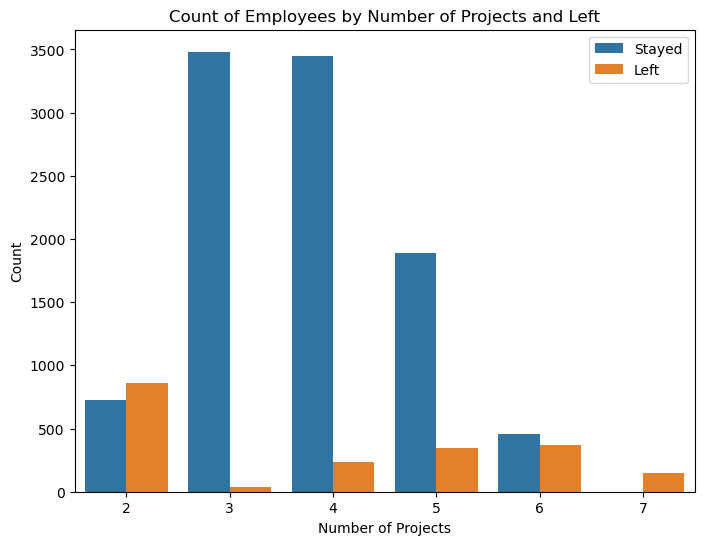

In [27]:
# Bar plot of number of projects vs. left
plt.figure(figsize=(8, 6))
sns.countplot(
    data=df,
    x="number_project",
    hue="left",
)
plt.title("Count of Employees by Number of Projects and Left")
plt.xlabel("Number of Projects")
plt.ylabel("Count")
plt.legend(loc="upper right", labels=["Stayed", "Left"])
plt.show()

In [28]:
# Count and percentage for number_project and left (number_project first)
cross_counts = df.groupby(["number_project", "left"]).size().unstack(fill_value=0)
cross_percent = cross_counts.div(cross_counts.sum(axis=1), axis=0) * 100

summary = (
    cross_counts.astype(int)
    .join(cross_percent.round(2), lsuffix="_count", rsuffix="_percent")
    .reset_index()
    .melt(id_vars="number_project", value_name="Value", var_name="Status")
)

# Split Status into Left and Item
summary[["left", "Item"]] = summary["Status"].str.extract(r"(\d)_(count|percent)")
summary["left"] = summary["left"].map({"0": "Stayed", "1": "Left"})

# Pivot for easier viewing
summary = (
    summary.pivot_table(
        index=["number_project", "left"], columns="Item", values="Value"
    )
    .reset_index()
    .rename(
        columns={
            "number_project": "Number of Projects",
            "left": "Left",
            "count": "Count",
            "percent": "Percent",
        }
    )
)

summary["Count"] = summary["Count"].round().astype(int)
summary["Percent"] = summary["Percent"].astype(float).map("{:.2f}".format)

display(summary.style.hide(axis="index"))

Number of Projects,Left,Count,Percent
2,Left,857,54.17
2,Stayed,725,45.83
3,Left,38,1.08
3,Stayed,3482,98.92
4,Left,237,6.43
4,Stayed,3448,93.57
5,Left,343,15.36
5,Stayed,1890,84.64
6,Left,371,44.92
6,Stayed,455,55.08


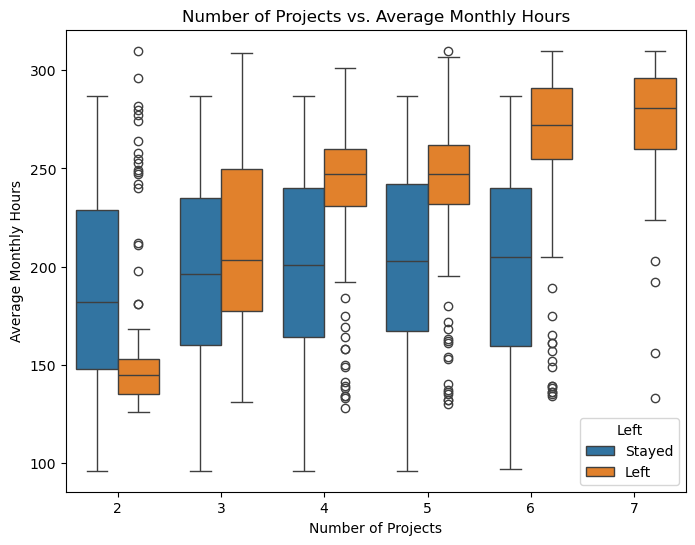

In [29]:
# Boxplot of number of projects vs. average monthly hours, split by left
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x="number_project",
    y="average_monthly_hours",
    hue="left",
)
plt.title("Number of Projects vs. Average Monthly Hours")
plt.xlabel("Number of Projects")
plt.ylabel("Average Monthly Hours")
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["Stayed", "Left"], title="Left", loc="lower right")
plt.show()

There are no notable outliers among employees who stayed. Among those who left, both overworked and underworked patterns are evident, along with a group who appear to have left for more typical reasons. For leavers with many projects (6 or 7), the IQR for monthly hours was very high, entirely above 240 hours/month. In fact, the IQR for almost every group was above a typical 40-hour work week (~167 hours / month). Interestingly, a few employees with 7 projects reported unusually low monthly hours, which may reflect data anomalies or unique circumstances.


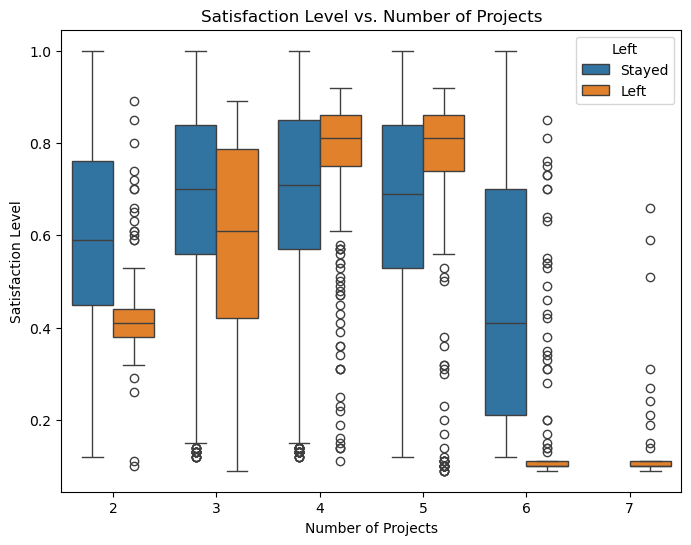

In [30]:
# Boxplot of satisfaction level vs number of projects, split by left
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x="number_project",
    y="satisfaction_level",
    hue="left",
)
plt.title("Satisfaction Level vs. Number of Projects")
plt.xlabel("Number of Projects")
plt.ylabel("Satisfaction Level")
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["Stayed", "Left"], title="Left", loc="upper right")
plt.show()

Among employees who left, dissatisfaction is most evident for those assigned a very high number of projects. Conversely, those with fewer projects also show signs of lower satisfaction, possibly indicating disengagement.


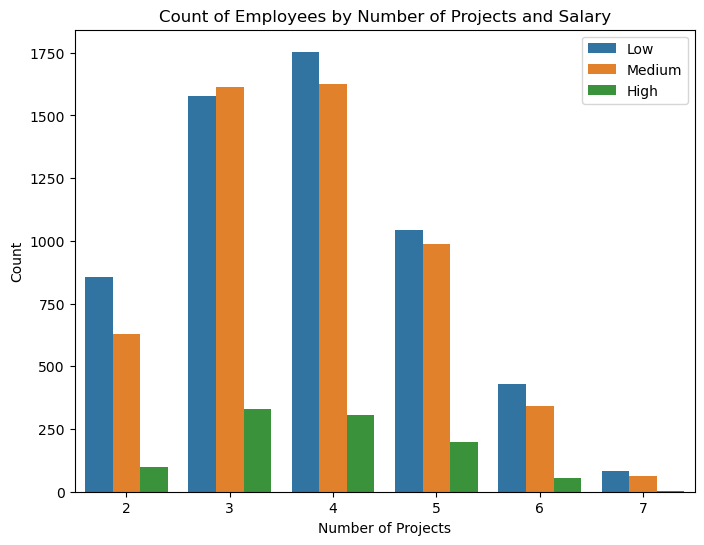

In [31]:
# Bar plot of number of projects vs salary
plt.figure(figsize=(8, 6))
sns.countplot(
    data=df,
    x="number_project",
    hue="salary",
)
plt.title("Count of Employees by Number of Projects and Salary")
plt.xlabel("Number of Projects")
plt.ylabel("Count")
plt.legend(loc="upper right", labels=["Low", "Medium", "High"])
plt.show()

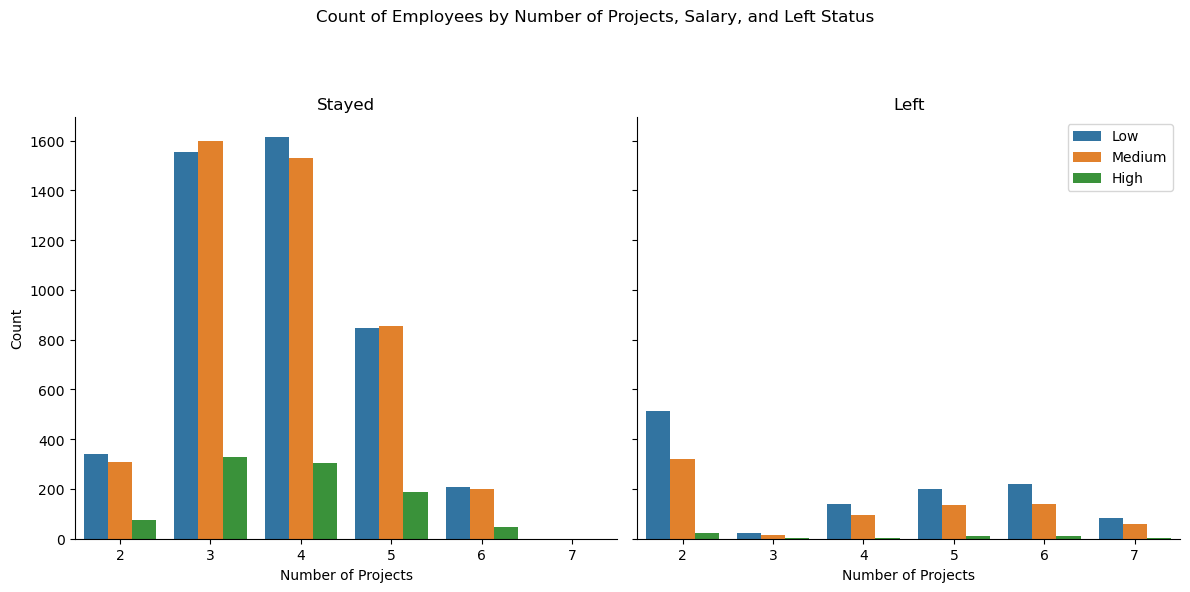

In [32]:
# Bar plot of number of projects vs salary, separated by left
g = sns.catplot(
    data=df,
    x="number_project",
    hue="salary",
    col="left",
    kind="count",
    height=6,
    aspect=1,
    legend=False,
)

# replace facet titles
new_titles = {0: "Stayed", 1: "Left"}
for ax, title in zip(g.axes.flat, g.col_names):
    ax.set_title(new_titles[int(title)])

# label axes
for ax in g.axes.flat:
    ax.set_xlabel("Number of Projects")
    ax.set_ylabel("Count")

plt.legend(loc="upper right", labels=["Low", "Medium", "High"])
plt.subplots_adjust(top=0.8)
plt.suptitle("Count of Employees by Number of Projects, Salary, and Left Status")
plt.show()

There are no clear patterns linking number of projects, salary, and attrition. However, the relatively small group of high-salaried employees tends to fall in the middle range for number of projects.

<div class="circle-separator-anchor"></div>

<a id="salary"></a>

## Salary & Promotions
---

[Back to top](#)

Salary does not show a discernible relationship with attrition; the 'high' salary group is much smaller than the others by an order of magnitude, limiting its impact on overall trends.

Promotions were rare and, notably, all of the employees with the highest workload left.


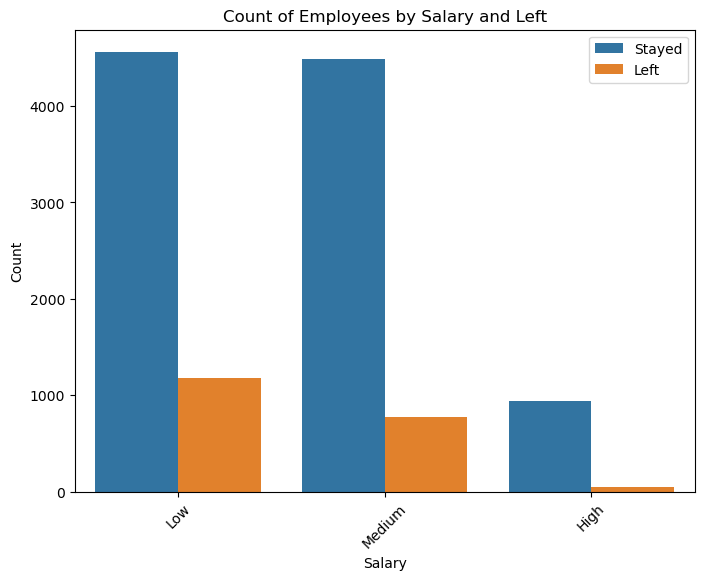

In [33]:
# Bar plot of salary vs. left
plt.figure(figsize=(8, 6))
ax = sns.countplot(
    data=df,
    x="salary",
    hue="left",
)
plt.title("Count of Employees by Salary and Left")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.legend(loc="upper right", labels=["Stayed", "Left"])
ax.set_xticklabels([label.get_text().capitalize() for label in ax.get_xticklabels()])
plt.xticks(rotation=45)
plt.show()

In [34]:
# Get total and percentage of employees by salary and left
salary_counts = df.groupby(["salary", "left"]).size().unstack(fill_value=0)
salary_percent = salary_counts.div(salary_counts.sum(axis=1), axis=0) * 100

salary_summary = (
    salary_counts.join(salary_percent, lsuffix="_count", rsuffix="_percent")
    .reset_index()
    .melt(id_vars="salary", value_name="Value", var_name="Status")
)

# Split Status into Left and Item
salary_summary[["Left", "Item"]] = salary_summary["Status"].str.extract(
    r"(\d)_(count|percent)"
)
salary_summary["Left"] = salary_summary["Left"].map({"0": "Stayed", "1": "Left"})

# Pivot so each row is salary + Left, with Count and Percent columns
salary_summary = (
    salary_summary.pivot_table(index=["salary", "Left"], columns="Item", values="Value")
    .reset_index()
    .rename(columns={"salary": "Salary", "count": "Count", "percent": "Percent"})
)

# Format the summary for better readability
salary_summary["Count"] = salary_summary["Count"].round().astype(int)
salary_summary["Percent"] = salary_summary["Percent"].astype(float).map("{:.2f}".format)
salary_summary["Salary"] = salary_summary["Salary"].str.title()

display(salary_summary.style.hide(axis="index"))

Salary,Left,Count,Percent
High,Left,48,4.85
High,Stayed,942,95.15
Low,Left,1174,20.45
Low,Stayed,4566,79.55
Medium,Left,769,14.62
Medium,Stayed,4492,85.38


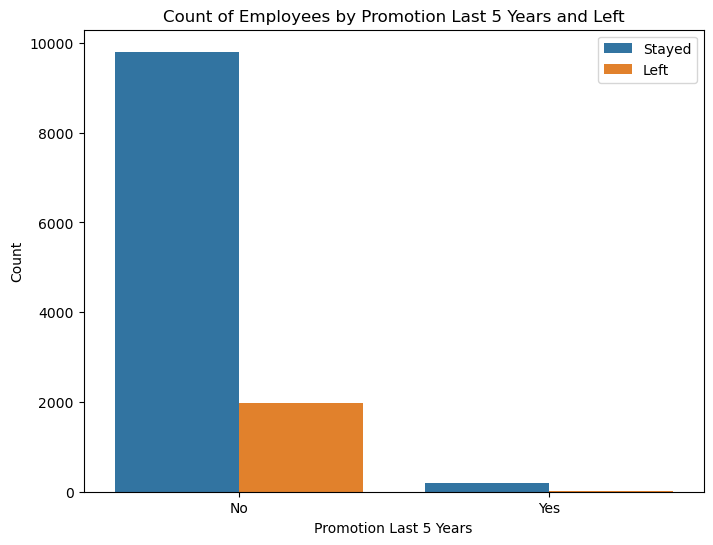

In [35]:
# Bar plot of promotion last 5 years vs. left
plt.figure(figsize=(8, 6))
ax = sns.countplot(
    data=df,
    x="promotion_last_5years",
    hue="left",
)
plt.title("Count of Employees by Promotion Last 5 Years and Left")
plt.xlabel("Promotion Last 5 Years")
plt.ylabel("Count")
plt.legend(loc="upper right", labels=["Stayed", "Left"])
ax.set_xticklabels(["No", "Yes"])
plt.show()

In [36]:
# Count and percentage for promotion_last_5years and left (promotion_last_5years first)
cross_counts = (
    df.groupby(["promotion_last_5years", "left"]).size().unstack(fill_value=0)
)
cross_percent = cross_counts.div(cross_counts.sum(axis=1), axis=0) * 100

summary = (
    cross_counts.astype(int)
    .join(cross_percent.round(2), lsuffix="_count", rsuffix="_percent")
    .reset_index()
    .melt(id_vars="promotion_last_5years", value_name="Value", var_name="Status")
)

# Split Status into Left and Item
summary[["left", "Item"]] = summary["Status"].str.extract(r"(\d)_(count|percent)")
summary["left"] = summary["left"].map({"0": "Stayed", "1": "Left"})
summary["promotion_last_5years"] = summary["promotion_last_5years"].map(
    {0: "No", 1: "Yes"}
)

# Pivot for easier viewing
summary = (
    summary.pivot_table(
        index=["promotion_last_5years", "left"], columns="Item", values="Value"
    )
    .reset_index()
    .rename(
        columns={
            "promotion_last_5years": "Promotion Last 5 Years",
            "left": "Left",
            "count": "Count",
            "percent": "Percent",
        }
    )
)

# Format the summary for better readability
summary["Count"] = summary["Count"].round().astype(int)
summary["Percent"] = summary["Percent"].astype(float).map("{:.2f}".format)

# Add total row for each Yes/No group
total_employees = (
    summary["Count"].sum() - summary[summary["Left"] == "Total"]["Count"].sum()
)  # exclude any previous total rows

total_rows = []
for val in summary["Promotion Last 5 Years"].unique():
    if val == "Total":
        continue
    group = summary[
        (summary["Promotion Last 5 Years"] == val) & (summary["Left"] != "Total")
    ]
    total_count = group["Count"].sum()
    percent_of_all = total_count / total_employees * 100
    total_rows.append(
        {
            "Promotion Last 5 Years": val,
            "Left": "Total",
            "Count": total_count,
            "Percent": f"{percent_of_all:.2f}",
        }
    )
summary = pd.concat([summary, pd.DataFrame(total_rows)], ignore_index=True)

display(summary.style.hide(axis="index"))

Promotion Last 5 Years,Left,Count,Percent
No,Left,1983,16.82
No,Stayed,9805,83.18
Yes,Left,8,3.94
Yes,Stayed,195,96.06
No,Total,11788,98.31
Yes,Total,203,1.69


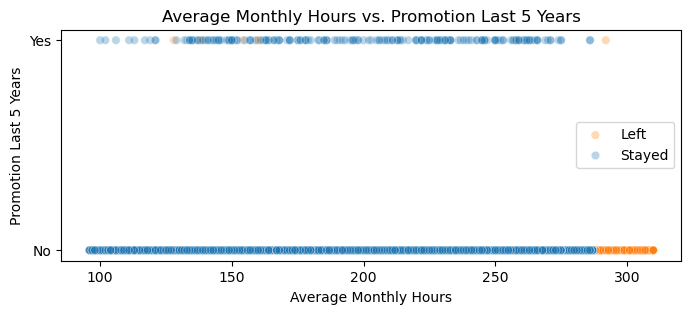

In [37]:
# Scatter plot average monthly hours vs. promotion last 5 years, colored by left
plt.figure(figsize=(8, 3))
sns.scatterplot(
    data=df,
    x="average_monthly_hours",
    y="promotion_last_5years",
    hue="left",
    alpha=0.3,
)
plt.title("Average Monthly Hours vs. Promotion Last 5 Years")
plt.xlabel("Average Monthly Hours")
plt.ylabel("Promotion Last 5 Years")
plt.yticks([0, 1], ["No", "Yes"])
plt.legend(loc="center right", labels=["Left", "Stayed"])
plt.show()

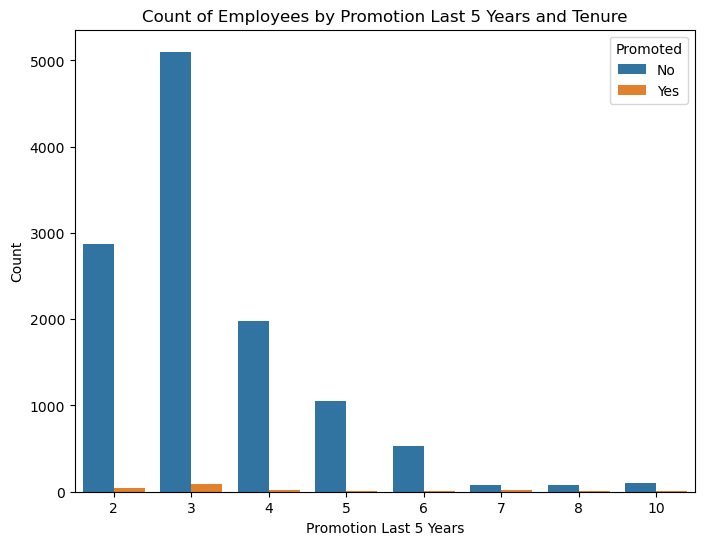

In [38]:
# Bar plot of promotion last 5 years and tenure
plt.figure(figsize=(8, 6))
sns.countplot(
    data=df,
    x="tenure",
    hue="promotion_last_5years",
)
plt.title("Count of Employees by Promotion Last 5 Years and Tenure")
plt.xlabel("Promotion Last 5 Years")
plt.ylabel("Count")
plt.legend(loc="upper right", title="Promoted", labels=["No", "Yes"])
plt.show()

<div class="circle-separator-anchor"></div>

<a id="work-accident"></a>

## Work Accident
---

[Back to top](#)

Somewhat unexpectedly, having a work accident is associated with a lower likelihood of leaving. This could suggest that employees who experience an accident may receive increased support or attention from HR or the company, which encourages them to stay. However, this association could also be coincidental.

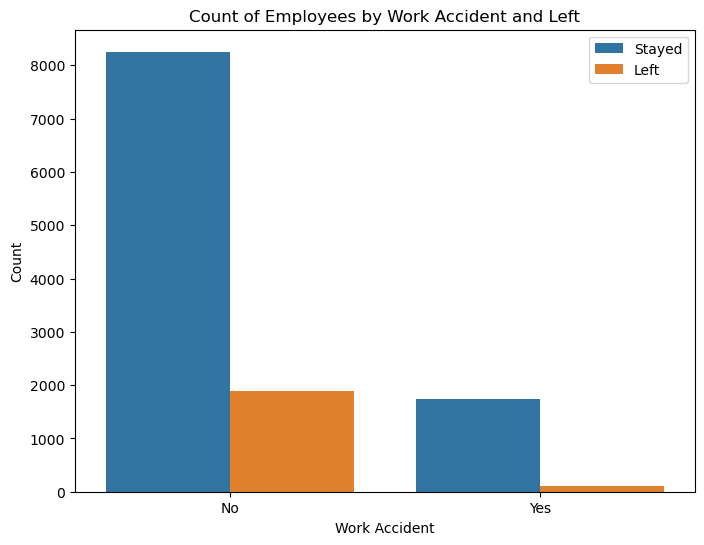

In [39]:
# Bar plot of work accident vs. left
plt.figure(figsize=(8, 6))
ax = sns.countplot(
    data=df,
    x="work_accident",
    hue="left",
)
plt.title("Count of Employees by Work Accident and Left")
plt.xlabel("Work Accident")
plt.ylabel("Count")
plt.legend(loc="upper right", labels=["Stayed", "Left"])
ax.set_xticklabels(["No", "Yes"])
plt.show()

In [40]:
# Count and percentage for work_accident and left (work_accident first)
cross_counts = df.groupby(["work_accident", "left"]).size().unstack(fill_value=0)
cross_percent = cross_counts.div(cross_counts.sum(axis=1), axis=0) * 100

summary = (
    cross_counts.astype(int)
    .join(cross_percent.round(2), lsuffix="_count", rsuffix="_percent")
    .reset_index()
    .melt(id_vars="work_accident", value_name="Value", var_name="Status")
)

# Split Status into Left and Item
summary[["left", "Item"]] = summary["Status"].str.extract(r"(\d)_(count|percent)")
summary["left"] = summary["left"].map({"0": "Stayed", "1": "Left"})
summary["work_accident"] = summary["work_accident"].map({0: "No", 1: "Yes"})

# Pivot for easier viewing
summary = (
    summary.pivot_table(index=["work_accident", "left"], columns="Item", values="Value")
    .reset_index()
    .rename(
        columns={
            "work_accident": "Work Accident",
            "left": "Left",
            "count": "Count",
            "percent": "Percent",
        }
    )
)

# Format the summary for better readability
summary["Count"] = summary["Count"].round().astype(int)
summary["Percent"] = summary["Percent"].astype(float).map("{:.2f}".format)

display(summary.style.hide(axis="index"))

Work Accident,Left,Count,Percent
No,Left,1886,18.60
No,Stayed,8255,81.40
Yes,Left,105,5.68
Yes,Stayed,1745,94.32


<div class="circle-separator-anchor"></div>

<a id="department"></a>

## Department
---

[Back to top](#)

Department-level attrition closely matches the overall stay/leave split (83%/17%) and company-wide satisfaction levels, suggesting department itself is not a major factor. More granular data (e.g., by manager or team) might uncover specific problem areas, but nothing stands out in the current breakdown.

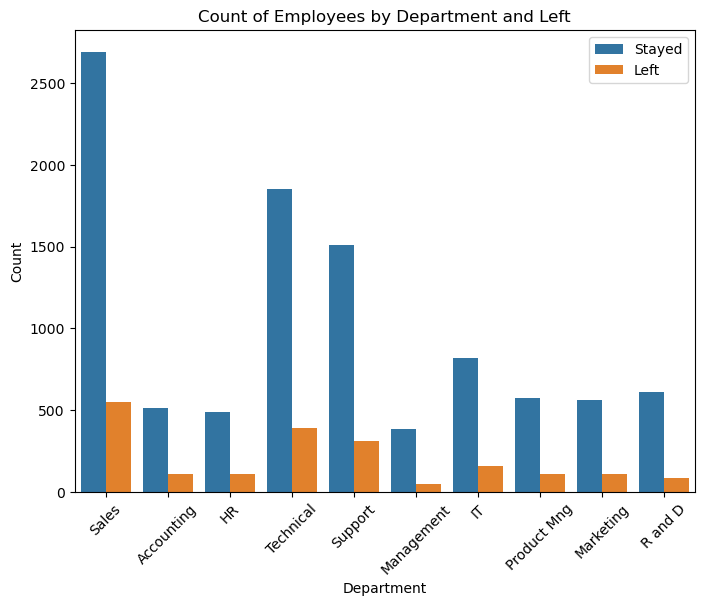

In [41]:
# Bar plot of department vs. left
plt.figure(figsize=(8, 6))
ax = sns.countplot(
    data=df,
    x="department",
    hue="left",
)
plt.title("Count of Employees by Department and Left")
plt.xlabel("Department")
plt.ylabel("Count")
plt.legend(loc="upper right", labels=["Stayed", "Left"])
# format_department function near top of notebook
ax.set_xticklabels(
    [format_department(label.get_text()) for label in ax.get_xticklabels()]
)
plt.xticks(rotation=45)
plt.show()

In [42]:
# get total and percentage of employees by department and left
dept_counts = df.groupby(["department", "left"]).size().unstack(fill_value=0)

# percentages within each department (row-wise)
dept_percent = dept_counts.div(dept_counts.sum(axis=1), axis=0) * 100

# reshape: melt to long format
dept_summary = (
    dept_counts.join(dept_percent, lsuffix="_count", rsuffix="_percent")
    .reset_index()
    .melt(id_vars="department", value_name="Value", var_name="Status")
)

# split Status into Left and Item
dept_summary[["Left", "Item"]] = dept_summary["Status"].str.extract(
    r"(\d)_(count|percent)"
)
dept_summary["Left"] = dept_summary["Left"].map({"0": "Stayed", "1": "Left"})

# pivot so each row is department + Left, with Count and Percent columns
dept_summary = (
    dept_summary.pivot_table(
        index=["department", "Left"], columns="Item", values="Value"
    )
    .reset_index()
    .rename(
        columns={"department": "Department", "count": "Count", "percent": "Percent"}
    )
)

# round Percent
dept_summary["Percent"] = dept_summary["Percent"].round(2)

# format summary table - format_department function near top of notebook
dept_summary["Department"] = dept_summary["Department"].apply(format_department)
dept_summary["Count"] = dept_summary["Count"].astype(int)
dept_summary["Percent"] = dept_summary["Percent"].astype(float).map("{:.2f}".format)

display(dept_summary.style.hide(axis="index"))

Department,Left,Count,Percent
IT,Left,158,16.19
IT,Stayed,818,83.81
R and D,Left,85,12.25
R and D,Stayed,609,87.75
Accounting,Left,109,17.55
Accounting,Stayed,512,82.45
HR,Left,113,18.80
HR,Stayed,488,81.20
Management,Left,52,11.93
Management,Stayed,384,88.07


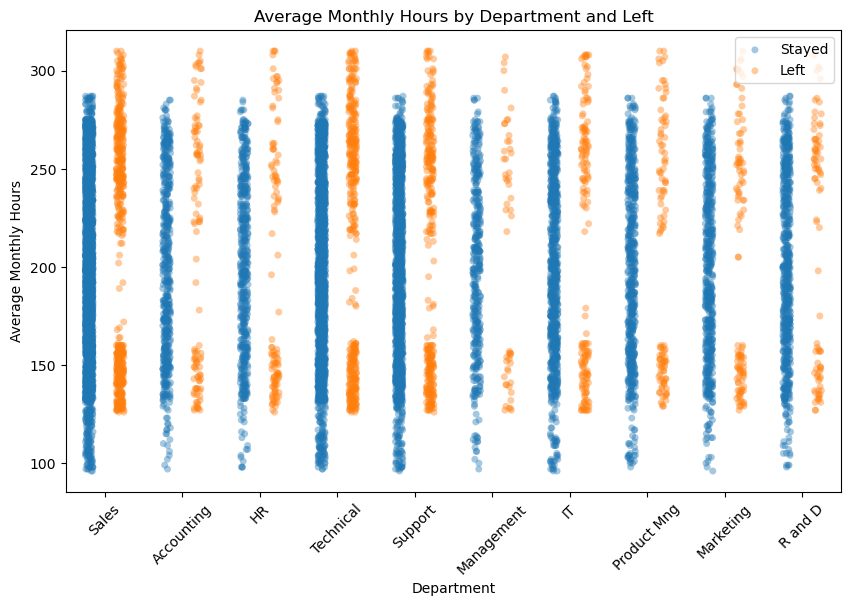

In [43]:
# Scatter plot of average monthly hours vs. department, colored by left
plt.figure(figsize=(10, 6))
ax = sns.stripplot(
    data=df,
    x="department",
    y="average_monthly_hours",
    hue="left",
    dodge=True,
    alpha=0.4,
    jitter=True,
)
plt.title("Average Monthly Hours by Department and Left")
plt.xlabel("Department")
plt.ylabel("Average Monthly Hours")
plt.legend(loc="upper right", labels=["Stayed", "Left"])
# format_department function near top of notebook
ax.set_xticklabels(
    [format_department(label.get_text()) for label in ax.get_xticklabels()]
)
plt.xticks(rotation=45)
plt.show()

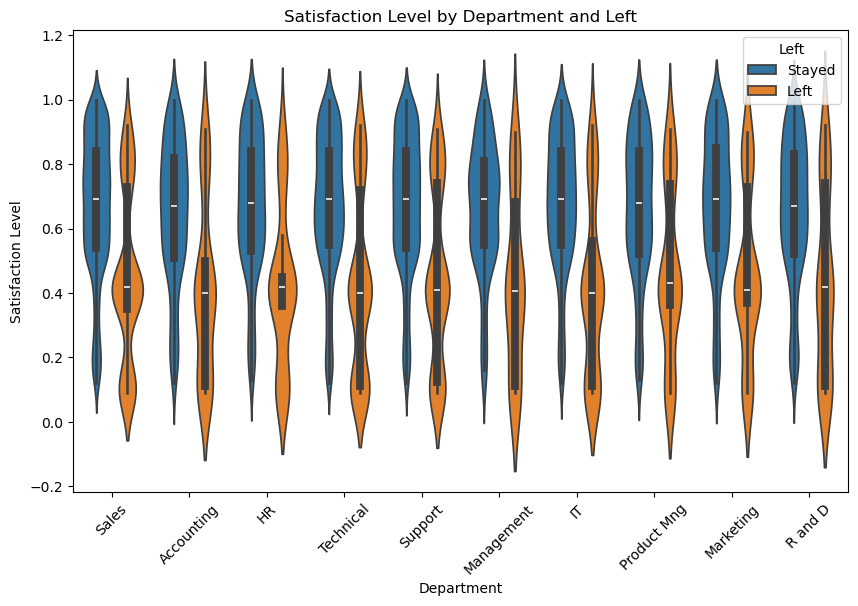

In [44]:
# Box plot of satisfaction level vs. department, split by left
plt.figure(figsize=(10, 6))
ax = sns.violinplot(
    data=df,
    x="department",
    y="satisfaction_level",
    hue="left",
)
plt.title("Satisfaction Level by Department and Left")
plt.xlabel("Department")
plt.ylabel("Satisfaction Level")
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["Stayed", "Left"], title="Left", loc="upper right")
# format_department function near top of notebook
ax.set_xticklabels(
    [format_department(label.get_text()) for label in ax.get_xticklabels()]
)
plt.xticks(rotation=45)
plt.show()

<div class="circle-separator-anchor"></div>

<a id="correlation-matrix"></a>

## Correlation Matrix
---

[Back to top](#)

The correlation matrix shows moderate correlation between some variables. Employee attrition (leaving) is most strongly and negatively correlated with satisfaction level, indicating that less satisfied employees are more likely to leave. There are moderate positive correlations between average monthly hours, last evaluation, and number of projects, as well as a moderate association between tenure and attrition.

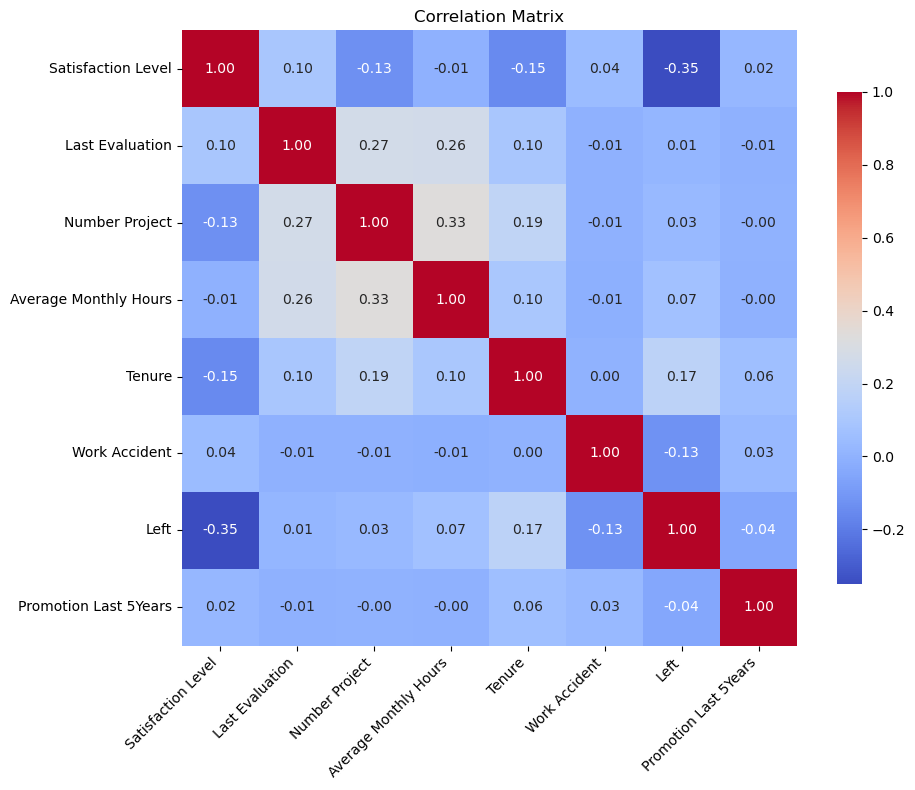

In [45]:
# Correlation matrix
plt.figure(figsize=(10, 8))

corr = df.select_dtypes(include=[np.number]).corr()
ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8},
)

ax.set_xticklabels(
    [label.replace("_", " ").title() for label in corr.columns], rotation=45, ha="right"
)
ax.set_yticklabels(
    [label.replace("_", " ").title() for label in corr.index], rotation=0
)
plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

<div class="circle-separator-anchor"></div>

<a id="insights"></a>

# **Insights**
---

[Back to Top](#)

The data suggests significant challenges with employee retention at this company. Two main groups of leavers emerge:

- **Underutilized and Dissatisfied:** Employees in this category worked on fewer projects and logged fewer hours than a typical full-time schedule, and reported lower satisfaction. These individuals may have been disengaged, assigned less work as they prepared to leave, or potentially subject to layoffs or terminations.
- **Overworked and Burned Out:** The second group managed a high number of projects (up to 7) and worked exceptionally long hours, sometimes nearing 80 hours per week. These employees exhibited very low satisfaction and rarely received promotions, suggesting that high demands without recognition or advancement led to burnout and resignation.

A majority of the workforce greatly exceeds the typical 40-hour work week (160–184 hours per month), pointing to a workplace culture that expects long hours. The combination of high workload and limited opportunities for advancement likely fuels dissatisfaction and increases the risk of turnover.

Performance evaluations show only a weak link to attrition; both those who left and those who stayed received similar review scores. This indicates that strong performance alone does not guarantee retention, especially if employees are overworked or lack opportunities for growth.

Other variables, such as department, salary, and work accidents, do not show strong predictive value for employee churn compared to satisfaction and workload. Overall, **the data points to issues with workload management** and limited career progression as the main factors driving employee turnover at this company.

<h3 class="button-section-title">Continue Exploring:</h3>

<div class="button-row">
  <div class="button">
    <a href="../index.html">Executive Summary</a>
  </div>
  <div class="button">
    <a href="models.html">Model Construction</a>
  </div>
</div>

<div class="circle-separator-anchor"></div>

<!-- Footer -->
<footer class="site-footer" role="contentinfo">
  <span class="footer-tagline">Fluent in Data. Fluent in Human.</span>
  <span class="footer-owner">
    &copy; <span id="copyright-year">2025</span>
    <span class="footer-author">Bryan C. Johns</span>
  </span>
  <span class="footer-links">
    <a href="https://informedwanderer.com" target="_blank" class="portfolio-link" aria-label="Portfolio">
      <i class="fas fa-laptop-code footer-icon" aria-hidden="true" title="Portfolio"></i>Portfolio
    </a>
    <a href="https://www.linkedin.com/in/b-johns/" target="_blank" class="linkedin-link" aria-label="LinkedIn">
      <i class="fab fa-linkedin footer-icon" aria-hidden="true" title="LinkedIn"></i>LinkedIn
    </a>
    <a href="https://github.com/johbry17/Salifort-Employee-Churn-ml" target="_blank" class="github-link" aria-label="GitHub">
      <i class="fab fa-github footer-icon" aria-hidden="true" title="GitHub"></i>GitHub
    </a>
  </span>
</footer>
<script>
  // Auto-update year
  const yearElement = document.getElementById("copyright-year");
  if (yearElement) {
    yearElement.textContent = new Date().getFullYear();
  }
</script>

<script src="https://cdn.jsdelivr.net/npm/bootstrap@5.3.3/dist/js/bootstrap.bundle.min.js"></script>
<script src="../static/js/scripts.js"></script>
<script>
  document.addEventListener('DOMContentLoaded', function() {
    insertCircleSeparator('.circle-separator-anchor');
  });
</script>
